### **1.Descrição do DataSet**

Nome do dataset: Prouni - Relatório de Dados Abertos 2020

Link original: https://dados.gov.br/dados/conjuntos-dados/mec-prouni

Órgão responsável: Ministério da Educação (MEC)

Descrição do tema e finalidade: O dataset reúne informações detalhadas sobre as bolsas de estudo (integrais e parciais) concedidas pelo Programa Universidade para Todos (Prouni) no ano de 2020. Sua finalidade é permitir a transparência e a análise do perfil socioeconômico dos beneficiários, bem como a distribuição das bolsas por curso, instituição e região.

Número de registros: 166.830 linhas
Número de colunas: 15 colunas


Significado de variáveis importantes:

TIPO_BOLSA: Indica se a bolsa é Integral (100%) ou Parcial (50%).

MODALIDADE_ENSINO_BENEFICIARIO: Identifica se o curso é presencial ou a distância (EAD).

NOME_CURSO_BENEFICIARIO: Nome da graduação escolhida pelo aluno.

SEXO_BENEFICIARIO: Gênero autodeclarado do bolsista.

RACA_BENEFICIARIO: Perfil étnico-racial.

DATA_NASCIMENTO: Data de nascimento do aluno.

REGIAO_BENEFICIARIO: Localização geográfica do beneficiário no Brasil.


## 2.Exploração Estatística no Notebook

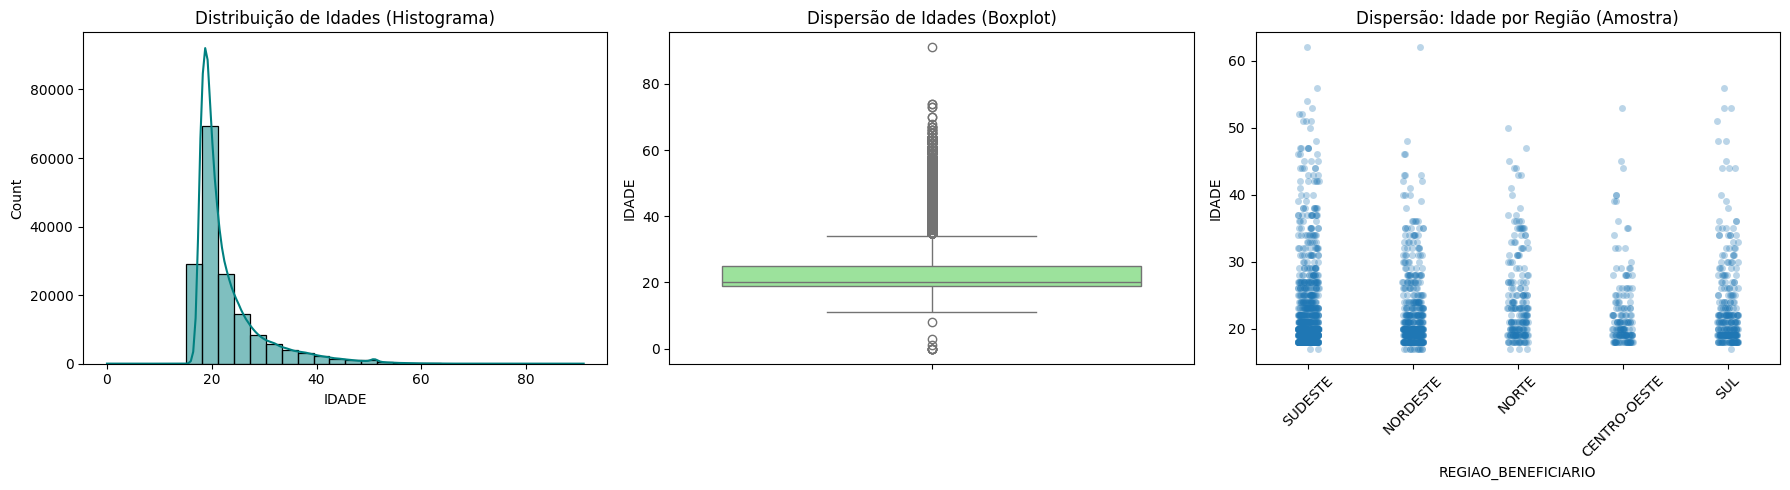

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/ProuniRelatorioDadosAbertos2020.csv', sep = ";", encoding='latin1')

df["DATA_NASCIMENTO"] = pd.to_datetime(df["DATA_NASCIMENTO"], dayfirst=True , errors='coerce')
df["IDADE"] = 2020 - df['DATA_NASCIMENTO'].dt.year

estatisticas = {
    "Media" : df["IDADE"].mean(),
    "Mediana" : df["IDADE"].median(),
    "Moda" : df["IDADE"].mode(),
    "Minimo" : df["IDADE"].min(),
    "Maximo" : df["IDADE"].max(),
    "Desvio Padrao" : df["IDADE"].std(),
    "Variancia" : df["IDADE"].var(),
    "Q1" : df["IDADE"].quantile(0.25),
    "Q3" : df["IDADE"].quantile(0.75),
    "IQR" : df["IDADE"].quantile(0.75) - df["IDADE"].quantile(0.25)
}

plt.figure(figsize=(18, 5))

# Histograma: Ver a concentração de idade
plt.subplot(1, 3, 1)
sns.histplot(df['IDADE'], bins=30, kde=True, color='teal')
plt.title('Distribuição de Idades (Histograma)')

# Boxplot: Ver os Quartis e Outliers
plt.subplot(1, 3, 2)
sns.boxplot(y=df['IDADE'], color='lightgreen')
plt.title('Dispersão de Idades (Boxplot)')

# Gráfico de Dispersão (Idade por Região para observar padrões)
plt.subplot(1, 3, 3)
sns.stripplot(x='REGIAO_BENEFICIARIO', y='IDADE', data=df.sample(2000), alpha=0.3)
plt.xticks(rotation=45)
plt.title('Dispersão: Idade por Região (Amostra)')

plt.tight_layout()
plt.show()



## 4. Análise e Comentários dos Resultados

Ao observar as estatísticas e os gráficos gerados, notei os seguintes pontos:

Assimetria à Direita (Idade): A média de idade é superior à mediana. Isso indica uma distribuição "assimétrica à direita", o que significa que, embora a gande maioria dos bolsistas seja de jovens 18 a 22 anos, existe um grupo menor de pessoas mais velhas que "puxa" a média para cima, isso pode decorrer de pessoas que desejam almejar outras graduações e até mesmo que pessoas mais velhas estão tendo acesso as universidades para conseguir realizar sua primeira graduação.

Presença de Outliers: O Boxplot revelou uma grande quantidade de valores discrepantes acima do limite superior. Isso mostra que o PROUNI em 2020 não atendeu apenas recém-saídos do Ensino Médio, mas também adultos alguns acima de 40 ou 50 anos em busca de requalificação profissional, mais uma vez provando que o programa consegue chegar nas pessoas com mais idade por mais que não seja o objetivo primario do programa ele se torna porta de entrada para outro grupo de pessoas tambem.

Concentração na Moda: A moda ser baixa confirma que o programa cumpre seu papel social principal de dar continuidade aos estudos logo após o ensino Médio, sendo um programa que democratiza o espaço da universidade para os mais jovens.

Diversidade Regional: Através da coluna REGIAO_BENEFICIARIO e do gráfico de dispersão, observa-se que o perfil de idade dos bolsistas é constante em todas as regiões (Norte, Nordeste, Centro-Oeste, Sudeste e Sul). Não há uma região onde os bolsistas sejam drasticamente mais velhos, o que permite inferir que, independente da localização geográfica, o programa atinge seu público-alvo de forma homogênea em todo o território nacional.